In [1]:
# import 'Pandas'
import pandas as pd

# import 'Numpy'
import numpy as np

# import subpackage of Matplotlib
import matplotlib.pyplot as plt

# import 'Seaborn'
import seaborn as sns

# to suppress warnings
from warnings import filterwarnings
filterwarnings('ignore')

# display all columns of the dataframe
pd.options.display.max_columns = None

# display all rows of the dataframe
pd.options.display.max_rows = None

# to display the float values upto 6 decimal places
pd.options.display.float_format = '{:.6f}'.format

# import train-test split
from sklearn.model_selection import train_test_split

# import various functions from statsmodels
import statsmodels
import statsmodels.api as sm

# import 'stats'
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.model_selection import cross_val_score
# import function to perform GridSearchCV
from sklearn.model_selection import GridSearchCV
plt.rcParams["figure.figsize"]=[15,8]

In [2]:
stroke_df=pd.read_csv("stroke.csv")
stroke_df.head()

,ID,Gender,Age,Hypertension,Heart_Disease,Ever_Married,Work_Type,Residence_Type,Avg_Glucose_Level,BMI,Smoking_Status,Stroke
0,30669,Male,3.000000,0,0,No,children,Rural,95.120000,18.000000,NaN,0
1,30468,Male,58.000000,1,0,Yes,Private,Urban,87.960000,39.200000,never smoked,0
2,16523,Female,8.000000,0,0,No,Private,Urban,110.890000,17.600000,NaN,0
3,56543,Female,70.000000,0,0,Yes,Private,Rural,69.040000,35.900000,formerly smoked,0
4,46136,Male,14.000000,0,0,No,Never_worked,Rural,161.280000,19.100000,NaN,0


In [3]:
stroke_df1=stroke_df.copy()

In [4]:
stroke_df.dtypes

ID                     int64
Gender                object
Age                  float64
Hypertension           int64
Heart_Disease          int64
Ever_Married          object
Work_Type             object
Residence_Type        object
Avg_Glucose_Level    float64
BMI                  float64
Smoking_Status        object
Stroke                 int64
dtype: object

In [5]:
stroke_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43400 entries, 0 to 43399
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 43400 non-null  int64  
 1   Gender             43400 non-null  object 
 2   Age                43400 non-null  float64
 3   Hypertension       43400 non-null  int64  
 4   Heart_Disease      43400 non-null  int64  
 5   Ever_Married       43400 non-null  object 
 6   Work_Type          43400 non-null  object 
 7   Residence_Type     43400 non-null  object 
 8   Avg_Glucose_Level  43400 non-null  float64
 9   BMI                41938 non-null  float64
 10  Smoking_Status     30108 non-null  object 
 11  Stroke             43400 non-null  int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 4.0+ MB


In [6]:
stroke_df.duplicated().sum()

np.int64(0)

In [7]:
stroke_df.drop(columns=["ID"],inplace=True)

In [8]:
stroke_df.describe()

,Age,Hypertension,Heart_Disease,Avg_Glucose_Level,BMI,Stroke
count,43400.000000,43400.000000,43400.000000,43400.000000,41938.000000,43400.000000
mean,42.217894,0.093571,0.047512,104.482750,28.605038,0.018041
std,22.519649,0.291235,0.212733,43.111751,7.770020,0.133103
min,0.080000,0.000000,0.000000,55.000000,10.100000,0.000000
25%,24.000000,0.000000,0.000000,77.540000,23.200000,0.000000
50%,44.000000,0.000000,0.000000,91.580000,27.700000,0.000000
75%,60.000000,0.000000,0.000000,112.070000,32.900000,0.000000
max,82.000000,1.000000,1.000000,291.050000,97.600000,1.000000


In [9]:
stroke_df.describe(include=object)

,Gender,Ever_Married,Work_Type,Residence_Type,Smoking_Status
count,43400,43400,43400,43400,30108
unique,3,2,5,2,3
top,Female,Yes,Private,Urban,never smoked
freq,25665,27938,24834,21756,16053


In [10]:
stroke_df.isnull().sum()

Gender                   0
Age                      0
Hypertension             0
Heart_Disease            0
Ever_Married             0
Work_Type                0
Residence_Type           0
Avg_Glucose_Level        0
BMI                   1462
Smoking_Status       13292
Stroke                   0
dtype: int64

In [11]:
stroke_df.BMI.mode()[0]

np.float64(27.7)

In [12]:
stroke_df.BMI.fillna(stroke_df.BMI.mode()[0],inplace=True)

In [13]:
stroke_df.Smoking_Status.mode()[0]

'never smoked'

In [14]:
stroke_df.Smoking_Status.fillna(stroke_df.Smoking_Status.mode()[0],inplace=True)

In [15]:
stroke_df["Gender"].value_counts()

Gender
Female    25665
Male      17724
Other        11
Name: count, dtype: int64

In [16]:
majority=stroke_df["Gender"].mode()[0]

stroke_df["Gender"]=stroke_df["Gender"].replace("Other",majority)

In [17]:
stroke_df["Gender"].value_counts()
stroke_df["Gender"].unique()

array(['Male', 'Female'], dtype=object)

In [18]:
stroke_df["Age"]=stroke_df["Age"].astype(int)

In [19]:
stroke_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43400 entries, 0 to 43399
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             43400 non-null  object 
 1   Age                43400 non-null  int64  
 2   Hypertension       43400 non-null  int64  
 3   Heart_Disease      43400 non-null  int64  
 4   Ever_Married       43400 non-null  object 
 5   Work_Type          43400 non-null  object 
 6   Residence_Type     43400 non-null  object 
 7   Avg_Glucose_Level  43400 non-null  float64
 8   BMI                43400 non-null  float64
 9   Smoking_Status     43400 non-null  object 
 10  Stroke             43400 non-null  int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 3.6+ MB


In [20]:
stroke_df.isnull().sum()

Gender               0
Age                  0
Hypertension         0
Heart_Disease        0
Ever_Married         0
Work_Type            0
Residence_Type       0
Avg_Glucose_Level    0
BMI                  0
Smoking_Status       0
Stroke               0
dtype: int64

In [21]:
target_df=stroke_df["Stroke"]
feature_df=stroke_df.drop("Stroke",axis=1)

In [22]:
snum_cols=feature_df.select_dtypes(np.number)
scat_cols=feature_df.select_dtypes(object)
snum_cols.columns,scat_cols.columns

(Index(['Age', 'Hypertension', 'Heart_Disease', 'Avg_Glucose_Level', 'BMI'], dtype='object'),
 Index(['Gender', 'Ever_Married', 'Work_Type', 'Residence_Type',
        'Smoking_Status'],
       dtype='object'))

In [23]:
dummy_var=pd.get_dummies(data=scat_cols,dtype=int)
dummy_var.head()

,Gender_Female,Gender_Male,Ever_Married_No,Ever_Married_Yes,Work_Type_Govt_job,Work_Type_Never_worked,Work_Type_Private,Work_Type_Self-employed,Work_Type_children,Residence_Type_Rural,Residence_Type_Urban,Smoking_Status_formerly smoked,Smoking_Status_never smoked,Smoking_Status_smokes
0,0,1,1,0,0,0,0,0,1,1,0,0,1,0
1,0,1,0,1,0,0,1,0,0,0,1,0,1,0
2,1,0,1,0,0,0,1,0,0,0,1,0,1,0
3,1,0,0,1,0,0,1,0,0,1,0,1,0,0
4,0,1,1,0,0,1,0,0,0,1,0,0,1,0


In [24]:
## MAKING ALL INTEGER DATA TO RANGE SOMEWHERE AROUND 0 OR WE CAN SAY SCALE IT INTO SMALLER VALUES
x_scaler=StandardScaler()
num_scaled=x_scaler.fit_transform(snum_cols)
num_scaled_df=pd.DataFrame(num_scaled,columns=snum_cols.columns)
y=target_df
num_scaled_df.head()

,Age,Hypertension,Heart_Disease,Avg_Glucose_Level,BMI
0,-1.739133,-0.321296,-0.223342,-0.217176,-1.384161
1,0.700660,3.112398,-0.223342,-0.383258,1.390824
2,-1.517333,-0.321296,-0.223342,0.148621,-1.436520
3,1.232978,-0.321296,-0.223342,-0.822123,0.958869
4,-1.251174,-0.321296,-0.223342,1.317458,-1.240176


In [25]:
x=pd.concat([num_scaled_df,dummy_var],axis=1)
x.head()

,Age,Hypertension,Heart_Disease,Avg_Glucose_Level,BMI,Gender_Female,Gender_Male,Ever_Married_No,Ever_Married_Yes,Work_Type_Govt_job,Work_Type_Never_worked,Work_Type_Private,Work_Type_Self-employed,Work_Type_children,Residence_Type_Rural,Residence_Type_Urban,Smoking_Status_formerly smoked,Smoking_Status_never smoked,Smoking_Status_smokes
0,-1.739133,-0.321296,-0.223342,-0.217176,-1.384161,0,1,1,0,0,0,0,0,1,1,0,0,1,0
1,0.700660,3.112398,-0.223342,-0.383258,1.390824,0,1,0,1,0,0,1,0,0,0,1,0,1,0
2,-1.517333,-0.321296,-0.223342,0.148621,-1.436520,1,0,1,0,0,0,1,0,0,0,1,0,1,0
3,1.232978,-0.321296,-0.223342,-0.822123,0.958869,1,0,0,1,0,0,1,0,0,1,0,1,0,0
4,-1.251174,-0.321296,-0.223342,1.317458,-1.240176,0,1,1,0,0,1,0,0,0,1,0,0,1,0


In [26]:
## SPLITING AND CHECKING SHAPES OF BOTH TRAIN AND SPLIT DATA
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=10,test_size=0.2)
print("x_train",x_train.shape)
print("y_train",y_train.shape)
print("x_test",x_test.shape)
print("y_test",y_test.shape)

x_train (34720, 19)
y_train (34720,)
x_test (8680, 19)
y_test (8680,)


In [27]:
# build a model on training dataset
# fit() is used to fit the OLS model
model = sm.Logit(y_train, x_train).fit()

# print the summary output
print(model.summary())

         Current function value: 0.073394
         Iterations: 35


C:\Users\smart\Desktop\python\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                           Logit Regression Results                           
Dep. Variable:                 Stroke   No. Observations:                34720
Model:                          Logit   Df Residuals:                    34705
Method:                           MLE   Df Model:                           14
Date:                Mon, 16 Feb 2026   Pseudo R-squ.:                  0.1838
Time:                        10:49:39   Log-Likelihood:                -2548.2
converged:                      False   LL-Null:                       -3122.2
Covariance Type:            nonrobust   LLR p-value:                2.809e-236
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Age                                1.5783      0.080     19.823      0.000       1.422       1.734
Hypertension                       0.0959      0.029      3.356      0.

In [28]:
logit=LogisticRegression(max_iter=1000,class_weight="balanced")
logit_model=logit.fit(x_train,y_train)
logit_model.score(x_test,y_test)

0.7464285714285714

In [29]:
y_pred=logit_model.predict(x_test)
y_pred

array([0, 0, 1, ..., 0, 1, 0], shape=(8680,))

In [30]:
accuracy=accuracy_score(y_test,y_pred)
print(f"accuracy : {round(accuracy,2)}")

accuracy : 0.75


In [31]:
cm=confusion_matrix(y_test,y_pred)
cm

array([[6355, 2165],
       [  36,  124]])

In [32]:
precision = precision_score(y_test,y_pred)
print("Precision score is : ",precision)
recall=recall_score(y_test,y_pred)
print("Recall score is : ",recall)
f1=f1_score(y_test,y_pred)
print("F1 score is : ",f1)

Precision score is :  0.05417212756662298
Recall score is :  0.775
F1 score is :  0.10126582278481013


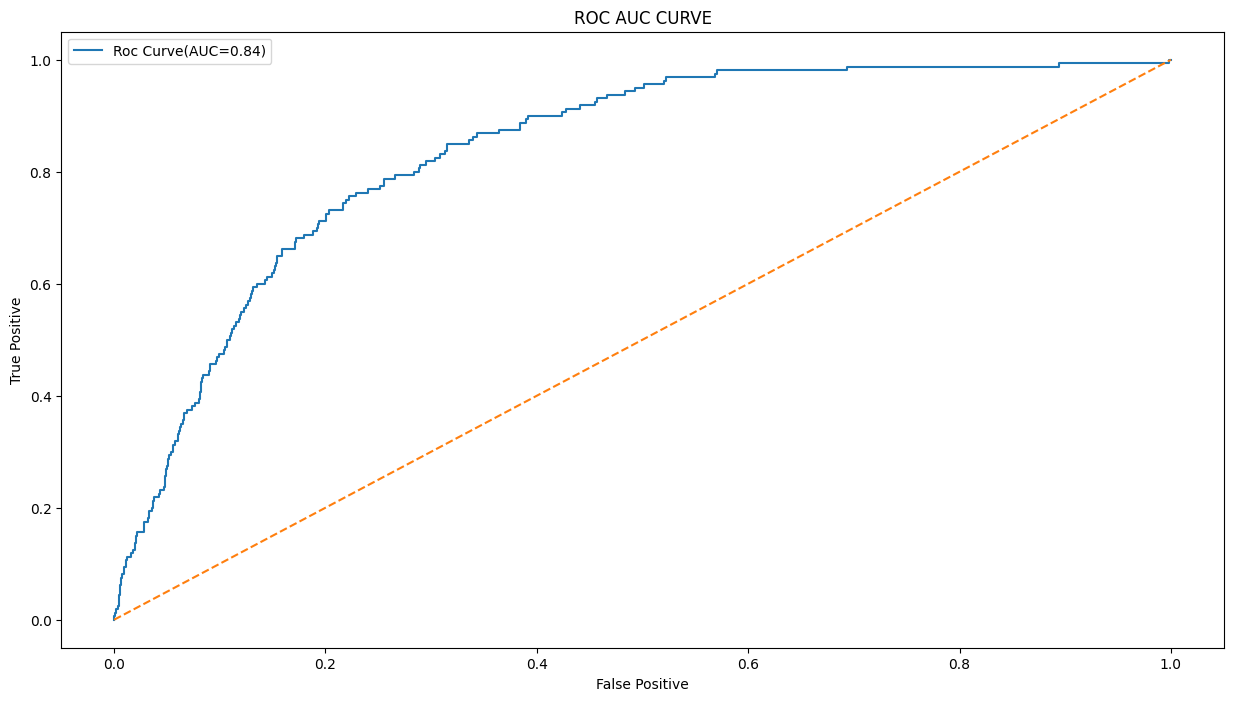

In [33]:
y_prob=logit_model.predict_proba(x_test)[:,1]
fpr,tpr,threshold=roc_curve(y_test,y_prob)
roc_auc=roc_auc_score(y_test,y_prob)
plt.figure()
plt.plot(fpr,tpr,label=f"Roc Curve(AUC={roc_auc:.2f})")
plt.plot([0,1],[0,1],linestyle="--")
plt.xlabel("False Positive")
plt.ylabel("True Positive")
plt.title("ROC AUC CURVE")
plt.legend()
plt.show()

In [34]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)
y_pred=knn.predict(x_test)
print("train data : ",knn.score(x_train, y_train),"\n","test data : ",knn.score(x_test, y_test))
print(f"Test Accuracy(k=5) : {accuracy_score(y_test,y_pred):.2f}")

train data :  0.9822580645161291 
 test data :  0.9812211981566821
Test Accuracy(k=5) : 0.98


In [35]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.98      1.00      0.99      8520
           1       0.00      0.00      0.00       160

    accuracy                           0.98      8680
   macro avg       0.49      0.50      0.50      8680
weighted avg       0.96      0.98      0.97      8680



In [36]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(x_train,y_train)
y_pred=nb.predict(x_test)
y_prob=nb.predict_proba(x_test)[:,1]

In [37]:
confusion_matrix(y_test, y_pred)

array([[2495, 6025],
       [   2,  158]])

In [38]:
print("ROC-AUC",roc_auc_score(y_test,y_prob))

ROC-AUC 0.7928726525821597


In [39]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      0.29      0.45      8520
           1       0.03      0.99      0.05       160

    accuracy                           0.31      8680
   macro avg       0.51      0.64      0.25      8680
weighted avg       0.98      0.31      0.45      8680

